This is a simple first pass at understanding how to work with openmc.  We'll try and reproduce the pin-cell (example)[https://nbviewer.org/github/openmc-dev/openmc-notebooks/blob/main/pincell.ipynb] 

The goal is to see how to work with the code in a simple example, and figure out the best way to bridge theory with example

This should be a model of a reflective pin-cell, which is the equivalent to modeling an infinite array of fuel pins. 

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import openmc

In [2]:
# Running openmc as is will usually crash when you call the plot() method.  This is because OPENMC_CROSS_SECTIONS is not set in the notebook environment
import os       
os.environ['OPENMC_CROSS_SECTIONS'] = os.path.expanduser(
    '~/openmc-data/endfb-viii.0-hdf5/cross_sections.xml'
)

Apparently we can generate materials with the Material class. Materials are defined as a set of nuclides with specified atom/weight fractions.  We define objects by unique ids, which are typically just a positive integer. We can also provide a name to make it easier to identify what the id is referring to

In [3]:
uo2 = openmc.Material(1, "uo2")

In [4]:
print(uo2)

Material
	ID             =	1
	Name           =	uo2
	Temperature    =	None
	Density        =	None [sum]
	Volume         =	None [cm^3]
	Depletable     =	False
	S(a,b) Tables  
	Nuclides       



In [5]:
mat = openmc.Material()

In [6]:
print(mat)

Material
	ID             =	2
	Name           =	
	Temperature    =	None
	Density        =	None [sum]
	Volume         =	None [cm^3]
	Depletable     =	False
	S(a,b) Tables  
	Nuclides       



In [7]:
help(uo2.add_nuclide)

Help on method add_nuclide in module openmc.material:

add_nuclide(nuclide: 'str', percent: 'float', percent_type: 'str' = 'ao') method of openmc.material.Material instance
    Add a nuclide to the material

    Parameters
    ----------
    nuclide : str
        Nuclide to add, e.g., 'Mo95'
    percent : float
        Atom or weight percent
    percent_type : {'ao', 'wo'}
        'ao' for atom percent and 'wo' for weight percent



In [8]:
# Add nuclides to our uo2 material
uo2.add_nuclide('U235', 0.03)
uo2.add_nuclide('U238', 0.97)
uo2.add_nuclide('O16', 2.0)

In [9]:
uo2.set_density('g/cm3', 10.0)

In [10]:
print(uo2)

Material
	ID             =	1
	Name           =	uo2
	Temperature    =	None
	Density        =	10.0 [g/cm3]
	Volume         =	None [cm^3]
	Depletable     =	True
	S(a,b) Tables  
	Nuclides       
	U235           =	0.03         [ao]
	U238           =	0.97         [ao]
	O16            =	2.0          [ao]



In [11]:
# We can add materials for the cladding and the coolant
zirconium = openmc.Material(name="zirconium")
zirconium.add_element("Zr", 1.0)
zirconium.set_density('g/cm3', 6.6)

water = openmc.Material(name='h20')
water.add_nuclide('H1', 2.0)
water.add_nuclide('O16', 1.0)
water.set_density('g/cm3', 1.0)

In [12]:
# So the water material we just created will only use free-atom cross sections.  We need to update this so that the bound atom cross section is used at thermal energies.  
water.add_s_alpha_beta('c_H_in_H2O')

In [13]:
# So it looks like the way this works is that when we try and run the transport solver, the first step is to look for a materials.xml file.  To create this file, we need to first instantiate a 
# Materials collection and export it to XML
materials = openmc.Materials([uo2, zirconium, water])

In [14]:
# We can append stuff to the materials class. It actually a subclass of a list
isinstance(materials, list)

True

In [15]:
materials.export_to_xml('../../../openmc_data/pincell_example')

In [16]:
!cat ../../../openmc_data/pincell_example/materials.xml

<?xml version='1.0' encoding='utf-8'?>
<materials>
  <material id="1" name="uo2" depletable="true">
    <density value="10.0" units="g/cm3"/>
    <nuclide name="U235" ao="0.03"/>
    <nuclide name="U238" ao="0.97"/>
    <nuclide name="O16" ao="2.0"/>
  </material>
  <material id="3" name="zirconium">
    <density value="6.6" units="g/cm3"/>
    <nuclide name="Zr90" ao="0.5145"/>
    <nuclide name="Zr91" ao="0.1122"/>
    <nuclide name="Zr92" ao="0.1715"/>
    <nuclide name="Zr94" ao="0.1738"/>
    <nuclide name="Zr96" ao="0.028"/>
  </material>
  <material id="4" name="h20">
    <density value="1.0" units="g/cm3"/>
    <nuclide name="H1" ao="2.0"/>
    <nuclide name="O16" ao="1.0"/>
    <sab name="c_H_in_H2O"/>
  </material>
</materials>


In [17]:
water.remove_nuclide('O16')
water.add_element('O', 1.0)
materials.export_to_xml('../../../openmc_data/pincell_example')

In [18]:
!cat ../../../openmc_data/pincell_example/materials.xml

<?xml version='1.0' encoding='utf-8'?>
<materials>
  <material id="1" name="uo2" depletable="true">
    <density value="10.0" units="g/cm3"/>
    <nuclide name="U235" ao="0.03"/>
    <nuclide name="U238" ao="0.97"/>
    <nuclide name="O16" ao="2.0"/>
  </material>
  <material id="3" name="zirconium">
    <density value="6.6" units="g/cm3"/>
    <nuclide name="Zr90" ao="0.5145"/>
    <nuclide name="Zr91" ao="0.1122"/>
    <nuclide name="Zr92" ao="0.1715"/>
    <nuclide name="Zr94" ao="0.1738"/>
    <nuclide name="Zr96" ao="0.028"/>
  </material>
  <material id="4" name="h20">
    <density value="1.0" units="g/cm3"/>
    <nuclide name="H1" ao="2.0"/>
    <nuclide name="O16" ao="0.9976206"/>
    <nuclide name="O17" ao="0.000379"/>
    <nuclide name="O18" ao="0.0020004"/>
    <sab name="c_H_in_H2O"/>
  </material>
</materials>


In [19]:
# !cat $OPENMC_CROSS_SECTIONS | head -n 10
# print('    ...')
# !cat $OPENMC_CROSS_SECTIONS | tail -n 10

In [20]:
# There's an additional method in add_element we can use called enrichment. For example, if we want to create a 3% enriched U02, we could do:
uo2_three = openmc.Material()
uo2_three.add_element('U', 1.0, enrichment=3.0)
uo2_three.add_element('O', 2.0)
uo2_three.set_density('g/cc', 10.0)

In [21]:
# We can create materials by mixing existing ones.  For example, MOX fuel out of UO2 (97 wt%) and PuO2 (3 wt%):
puo2 = openmc.Material()
puo2.add_nuclide('Pu239', 0.94)
puo2.add_nuclide('Pu240', 0.06)
puo2.add_nuclide('O16', 2.0)
puo2.set_density('g/cm3', 11.5)
mox = openmc.Material.mix_materials([uo2, puo2], [0.97, 0.03], 'wo') # wo here indicates weight fractions. 

In [22]:
sphere = openmc.Sphere(r=1.0)

In [23]:
inside_sphere = -sphere
outside_sphere = +sphere

In [24]:
print((0,0,0) in inside_sphere, (0,0,2) in inside_sphere)
print((0,0,0) in outside_sphere, (0,0,2) in outside_sphere)

True False
False True


In [25]:
# We can construct more complex volumes by combining half-spaces using Boolean operators. For example, the top part of the sphere (i.e. all points inside the sphere that have z > 0)
z_plane = openmc.ZPlane(0)
northern_hemisphere = -sphere & +z_plane

In [26]:
northern_hemisphere.bounding_box

BoundingBox(lower_left=(-1.0, -1.0, 0.0), upper_right=(1.0, 1.0, 1.0))

In [27]:
cell = openmc.Cell()
cell.region = northern_hemisphere

In [28]:
cell.fill = water

In [29]:
# A collection of cells is known as a universe and can be used as a repeatable unit when creating a model. The benefit of creating a universe is that we can visualize our geometry while we're creating it
universe = openmc.Universe()
universe.add_cell(cell)

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

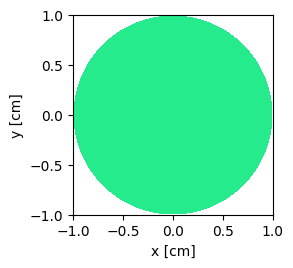

In [30]:
universe.plot(width=(2.0, 2.0), origin=(0.0, 0.0, 0.1))

<Axes: xlabel='x [cm]', ylabel='z [cm]'>

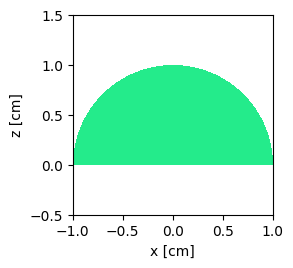

In [31]:
# By default, this plots in the x-y plane. We can change this with the basis argument 
universe.plot(width=(2.0, 2.0), basis='xz')

<Axes: xlabel='x [cm]', ylabel='z [cm]'>

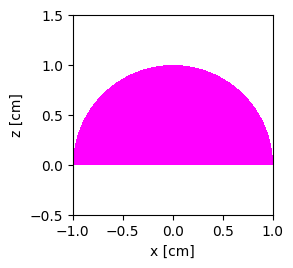

In [32]:
universe.plot(width=(2.0, 2.0), basis='xz', colors={cell: 'fuchsia'})

### Pin cell geometry

Now we can create a pin-cell.  We need three surfaces to define the fuel and clad:

1. The outer surface of the fuel -- a cylinder parallel to the z axis

2. The inner surface of the clad -- same as the above

3. The outer surface of the clad -- same as above

In [33]:
fuel_outer_radius = openmc.ZCylinder(r=0.39)
clad_inner_radius = openmc.ZCylinder(r=0.40)
clad_outer_radius = openmc.ZCylinder(r=0.46)

In [34]:
fuel_region = -fuel_outer_radius
gap_region = +fuel_outer_radius & -clad_inner_radius
clad_region = +clad_inner_radius & -clad_outer_radius

In [35]:
fuel = openmc.Cell(name='fuel')
fuel.fill = uo2
fuel.region = fuel_region 

gap = openmc.Cell(name='air gap')
gap.region = gap_region 

clad = openmc.Cell(name='clad')
clad.fill = zirconium
clad.region = clad_region

In [ ]:
# We also need to handle coolant outside of our fuel pin